# Notebook 05.6: New Baseline - Weighted EfficientNet-B0 + DenseNet121 Ensemble

From-scratch notebook for cardiomegaly classification using a **single ensemble model** that combines:

- EfficientNet-B0
- DenseNet121

Both backbones are fine-tuned jointly on the `train_val` images. Their logits are averaged to produce the final cardiomegaly probability.

The defaults are intentionally conservative so the joint model fits on laptop-class hardware.

Scoring target:

`0.5 * AUROC + 0.25 * Sensitivity + 0.25 * Specificity`


This version tests SGD with momentum instead of AdamW while keeping the rest of the 05.2 setup aligned.


This version keeps the joint ensemble setup but searches for the best EfficientNet/DenseNet blend on the validation set instead of assuming a fixed 50/50 split.


---
## Step 1: Imports

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)
from tqdm.auto import tqdm

print("Imports OK")


Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Device: {device}")


Device: mps


## Step 3: Configuration

In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 0
VAL_FRAC = 0.2
EPOCHS = 6
LR = 1e-3
MOMENTUM = 0.9
NESTEROV = True
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
TRAIN_EFNET_WEIGHT = 0.5
ENSEMBLE_WEIGHT_GRID = np.linspace(0.1, 0.9, 17)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"IMG_SIZE     : {IMG_SIZE}  # safer default for joint ensemble training")
print(f"BATCH_SIZE   : {BATCH_SIZE}  # reduced to avoid MPS/VRAM blowups")
print(f"EPOCHS       : {EPOCHS}")
print(f"LR           : {LR}  # SGD learning rate")
print(f"MOMENTUM     : {MOMENTUM}")
print(f"NESTEROV     : {NESTEROV}")
print(f"WEIGHT_DECAY : {WEIGHT_DECAY}")
print(f"TRAIN_EFNET_WEIGHT : {TRAIN_EFNET_WEIGHT}")
print(f"WEIGHT GRID        : {ENSEMBLE_WEIGHT_GRID.tolist()}")


IMG_SIZE     : 256  # safer default for joint ensemble training
BATCH_SIZE   : 4  # reduced to avoid MPS/VRAM blowups
EPOCHS       : 6
LR           : 0.001  # SGD learning rate
MOMENTUM     : 0.9
NESTEROV     : True
WEIGHT_DECAY : 0.0001
TRAIN_EFNET_WEIGHT : 0.5
WEIGHT GRID        : [0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35, 0.4, 0.45000000000000007, 0.5, 0.55, 0.6, 0.65, 0.7000000000000001, 0.75, 0.8, 0.85, 0.9]


## Step 4: Load labels

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df.head())
print("\nFinding counts:")
print(df["finding"].value_counts())
print(f"\nPositive rate: {df['label'].mean():.3f}")
print(f"Total         : {len(df)}")


       image_file  age sex       finding  label
0  IMG_000838.png   65   F  Cardiomegaly      1
1  IMG_000239.png   76   F  Cardiomegaly      1
2  IMG_000217.png   61   M    No Finding      0
3  IMG_001193.png   52   F    No Finding      0
4  IMG_001097.png   35   F    No Finding      0

Finding counts:
finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64

Positive rate: 0.456
Total         : 1578


## Step 5: Dataset

In [5]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)


## Step 6: Train / validation split

In [6]:
train_df, val_df = train_test_split(
    df,
    test_size=VAL_FRAC,
    stratify=df["label"],
    random_state=SEED,
)

print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")


Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


## Step 7: Transforms and loaders

In [7]:
def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=5),
            T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
            T.ColorJitter(brightness=0.1, contrast=0.1),
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

train_tf = build_transform(IMG_SIZE, augment=True)
val_tf = build_transform(IMG_SIZE, augment=False)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")


Train batches: 316
Val   batches: 79


## Step 8: Metrics helpers

In [8]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_score(y_true, y_prob):
    auroc = roc_auc_score(y_true, y_prob)
    best_thr = 0.5
    best_score = -1.0
    for thr in np.linspace(0.01, 0.99, 199):
        sens, spec = sens_spec(y_true, y_prob, threshold=thr)
        score = datathon_score(auroc, sens, spec)
        if score > best_score:
            best_thr = float(thr)
            best_score = float(score)
    return best_thr, best_score


def best_ensemble_weight(y_true, ef_probs, dn_probs, weights=None):
    if weights is None:
        weights = np.linspace(0.1, 0.9, 17)
    rows = []
    for w in weights:
        probs = w * ef_probs + (1.0 - w) * dn_probs
        thr, score = best_threshold_score(y_true, probs)
        sens, spec = sens_spec(y_true, probs, threshold=thr)
        auroc = roc_auc_score(y_true, probs)
        rows.append({
            "efnet_weight": float(w),
            "densenet_weight": float(1.0 - w),
            "thr": float(thr),
            "score": float(score),
            "auroc": float(auroc),
            "sens": float(sens),
            "spec": float(spec),
        })
    table = pd.DataFrame(rows).sort_values(["score", "auroc"], ascending=False).reset_index(drop=True)
    return table.iloc[0].to_dict(), table


## Step 9: Joint ensemble model

In [9]:
class EfficientDenseEnsemble(nn.Module):
    def __init__(self, dropout=DROPOUT, efnet_weight=TRAIN_EFNET_WEIGHT):
        super().__init__()
        self.efnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        ef_in = self.efnet.classifier[1].in_features
        self.efnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(ef_in, 1))

        self.efnet_weight = efnet_weight

        self.dnet = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        dn_in = self.dnet.classifier.in_features
        self.dnet.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(dn_in, 1))

    def forward_logits(self, x):
        ef_logits = self.efnet(x).squeeze(1)
        dn_logits = self.dnet(x).squeeze(1)
        return ef_logits, dn_logits

    def forward(self, x, efnet_weight=None):
        ef_logits, dn_logits = self.forward_logits(x)
        w = self.efnet_weight if efnet_weight is None else efnet_weight
        return w * ef_logits + (1.0 - w) * dn_logits

model = EfficientDenseEnsemble().to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.2f}%)")


Trainable: 10,963,710 / 10,963,710 (100.00%)


## Step 10: Train / eval helpers

In [10]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys = np.array(ys)
    ps = np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}


@torch.no_grad()
def predict_branch_probs(model, loader, device):
    model.eval()
    ys, ef_ps, dn_ps = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        ef_logits, dn_logits = model.forward_logits(imgs)
        ef_probs = torch.sigmoid(ef_logits).detach().cpu().numpy()
        dn_probs = torch.sigmoid(dn_logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ef_ps.extend(ef_probs.tolist())
        dn_ps.extend(dn_probs.tolist())
    return np.array(ys), np.array(ef_ps), np.array(dn_ps)

@torch.no_grad()
def predict_branch_probs_test(model, loader, device):
    model.eval()
    names, ef_ps, dn_ps = [], [], []
    for imgs, batch_names in loader:
        imgs = imgs.to(device)
        ef_logits, dn_logits = model.forward_logits(imgs)
        ef_probs = torch.sigmoid(ef_logits).detach().cpu().numpy()
        dn_probs = torch.sigmoid(dn_logits).detach().cpu().numpy()
        names.extend(batch_names)
        ef_ps.extend(ef_probs.tolist())
        dn_ps.extend(dn_probs.tolist())
    return names, np.array(ef_ps), np.array(dn_ps)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, train_loader, val_loader, optimizer, scheduler, epochs, device, tag="ensemble"):
    pos_weight = torch.tensor(
        [train_df["label"].eq(0).sum() / train_df["label"].eq(1).sum()],
        dtype=torch.float32,
        device=device,
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    best = {"score": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = evaluate(model, val_loader, device)
        thr, tuned_score = best_threshold_score(val["y"], val["p"])
        sens_t, spec_t = sens_spec(val["y"], val["p"], threshold=thr)
        dt = time.time() - t0
        history.append({
            "epoch": epoch,
            "loss": tr_loss,
            "auroc": val["auroc"],
            "sens": sens_t,
            "spec": spec_t,
            "thr": thr,
            "score": tuned_score,
        })
        star = ""
        if tuned_score > best["score"]:
            best = {
                "score": tuned_score,
                "auroc": val["auroc"],
                "sens": sens_t,
                "spec": spec_t,
                "thr": thr,
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        scheduler.step()
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {sens_t:.3f}  spec {spec_t:.3f}  "
            f"score {tuned_score:.4f}  thr {thr:.3f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, pd.DataFrame(history), best


## Step 11: Train the ensemble

In [11]:
optimizer = optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    nesterov=NESTEROV,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

model, history_df, best = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=EPOCHS,
    device=device,
    tag="efnet_densenet_joint_ensemble",
)

print("\nBest checkpoint:")
print(best)


[efnet_densenet_joint_ensemble] ep 01/6  loss 0.6890  AUROC 0.8534  sens 0.806  spec 0.738  score 0.8127  thr 0.510  (101.0s) ★


[efnet_densenet_joint_ensemble] ep 02/6  loss 0.6133  AUROC 0.9027  sens 0.840  spec 0.820  score 0.8663  thr 0.376  (93.0s) ★


[efnet_densenet_joint_ensemble] ep 03/6  loss 0.5751  AUROC 0.9401  sens 0.847  spec 0.872  score 0.8999  thr 0.505  (93.0s) ★


[efnet_densenet_joint_ensemble] ep 04/6  loss 0.5172  AUROC 0.9487  sens 0.979  spec 0.785  score 0.9154  thr 0.297  (97.8s) ★


[efnet_densenet_joint_ensemble] ep 05/6  loss 0.4674  AUROC 0.9459  sens 0.938  spec 0.826  score 0.9137  thr 0.540  (95.7s)


[efnet_densenet_joint_ensemble] ep 06/6  loss 0.4567  AUROC 0.9542  sens 0.896  spec 0.895  score 0.9249  thr 0.639  (95.3s) ★

Best checkpoint:
{'score': 0.9248829134366925, 'auroc': 0.9541747416020672, 'sens': 0.8958333333333334, 'spec': 0.8953488372093024, 'thr': 0.6385858585858586, 'state': OrderedDict([('efnet.features.0.0.weight', tensor([[[[ 1.2375e-01,  6.5868e-01,  4.5698e-01],
          [-1.0875e-01, -6.0675e-01, -3.3228e-01],
          [ 2.9049e-02, -1.0083e-01, -1.0294e-01]],

         [[ 6.5978e-02,  1.6565e+00,  1.7424e+00],
          [-1.3408e-01, -1.5323e+00, -1.5911e+00],
          [ 5.1408e-02, -1.1124e-01, -1.2568e-01]],

         [[ 8.9869e-02,  3.6395e-01,  2.6993e-01],
          [-1.1710e-01, -2.7824e-01, -2.1778e-01],
          [ 3.8095e-02, -6.8451e-02, -8.1643e-02]]],


        [[[ 1.6988e-01, -1.9461e-01,  8.9156e-02],
          [ 8.9229e-01, -1.2067e+00,  2.7924e-01],
          [ 1.0771e+00, -1.2547e+00,  2.1087e-01]],

         [[ 3.3337e-01, -4.2844e-01,  1

## Step 12: Plot training history

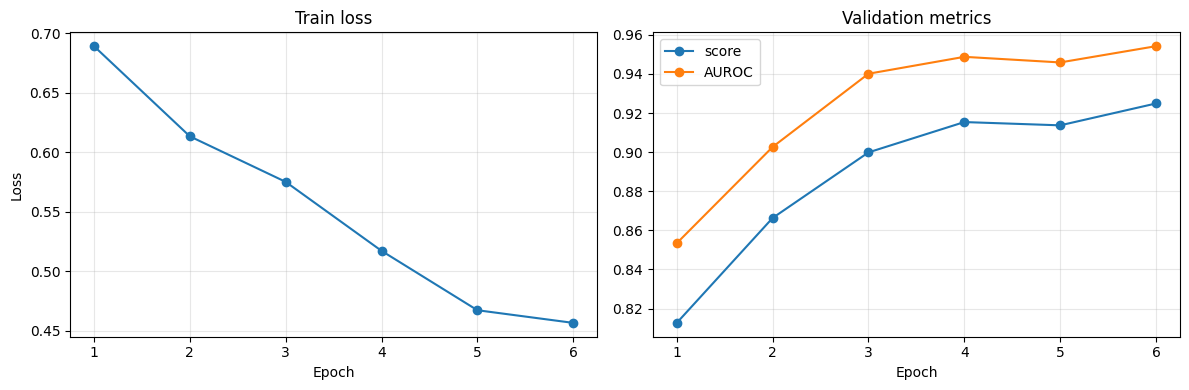

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["score"], marker="o", label="score")
axes[1].plot(history_df["epoch"], history_df["auroc"], marker="o", label="AUROC")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 13: Validation ROC, tuned threshold, and best ensemble weight


             mode  efnet_weight  densenet_weight      thr    score    auroc     sens     spec
train_time_weight           0.5              0.5 0.638586 0.924883 0.954175 0.895833 0.895349
  best_val_weight           0.4              0.6 0.653434 0.923793 0.951995 0.895833 0.895349

Top validation weight candidates:
 efnet_weight  densenet_weight      thr    score    auroc     sens     spec
         0.40             0.60 0.653434 0.923793 0.951995 0.895833 0.895349
         0.35             0.65 0.673232 0.922723 0.952762 0.895833 0.889535
         0.10             0.90 0.722727 0.922279 0.953650 0.909722 0.872093
         0.15             0.85 0.707879 0.922137 0.953367 0.909722 0.872093
         0.20             0.80 0.693030 0.922137 0.953367 0.909722 0.872093
         0.45             0.55 0.628687 0.922057 0.951429 0.895833 0.889535
         0.25             0.75 0.693030 0.921915 0.953488 0.902778 0.877907
         0.30             0.70 0.465354 0.921532 0.953448 0.965278 0.813953

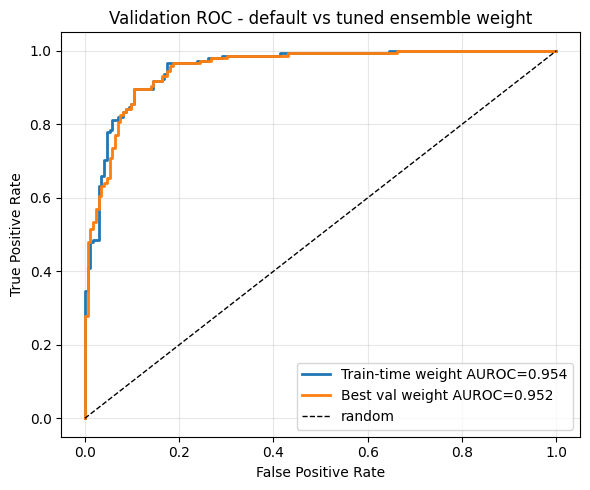

In [13]:
val = evaluate(model, val_loader, device)
default_thr, default_score = best_threshold_score(val["y"], val["p"])
default_sens, default_spec = sens_spec(val["y"], val["p"], threshold=default_thr)

y_val, ef_probs, dn_probs = predict_branch_probs(model, val_loader, device)
best_blend, weight_table = best_ensemble_weight(y_val, ef_probs, dn_probs, ENSEMBLE_WEIGHT_GRID)
blend_probs = best_blend["efnet_weight"] * ef_probs + best_blend["densenet_weight"] * dn_probs

summary_df = pd.DataFrame([
    {
        "mode": "train_time_weight",
        "efnet_weight": TRAIN_EFNET_WEIGHT,
        "densenet_weight": 1.0 - TRAIN_EFNET_WEIGHT,
        "thr": default_thr,
        "score": default_score,
        "auroc": val["auroc"],
        "sens": default_sens,
        "spec": default_spec,
    },
    {"mode": "best_val_weight", **best_blend},
])
print(summary_df.to_string(index=False))
print("\nTop validation weight candidates:")
print(weight_table.head(10).to_string(index=False))

best_thr = best_blend["thr"]
best_efnet_weight = best_blend["efnet_weight"]
best_densenet_weight = best_blend["densenet_weight"]

plt.figure(figsize=(6, 5))
fpr_default, tpr_default, _ = roc_curve(val["y"], val["p"])
fpr_weighted, tpr_weighted, _ = roc_curve(y_val, blend_probs)
plt.plot(fpr_default, tpr_default, lw=2, label=f"Train-time weight AUROC={val['auroc']:.3f}")
plt.plot(fpr_weighted, tpr_weighted, lw=2, label=f"Best val weight AUROC={best_blend['auroc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC - default vs tuned ensemble weight")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 14: Submission CSV with tuned ensemble weight


In [14]:
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")

test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

all_names, ef_test_probs, dn_test_probs = predict_branch_probs_test(model, test_loader, device)
all_probs = best_efnet_weight * ef_test_probs + best_densenet_weight * dn_test_probs

sub = pd.DataFrame({
    "image_file": all_names,
    "prob": all_probs,
})
sub["pred"] = (sub["prob"] >= best_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_05_6_weighted_efnet_densenet_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nUsing weights: EfficientNet={best_efnet_weight:.3f}, DenseNet={best_densenet_weight:.3f}, thr={best_thr:.3f}")
print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")


Test images: 176

Using weights: EfficientNet=0.400, DenseNet=0.600, thr=0.653

Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_05_6_weighted_efnet_densenet_20260421_1627.csv
       image_file      prob  pred
0  IMG_000018.png  0.817563     1
1  IMG_000021.png  0.153463     0
2  IMG_000039.png  0.677834     1
3  IMG_000044.png  0.657088     1
4  IMG_000047.png  0.660688     1

Positive rate in submission: 0.438
